In [122]:
from matplotlib import pyplot as plt
import statsmodels.api as sm
import pandas as pd
import seaborn as sns
import yfinance as yf
import numpy as np
import pandas_datareader as web

sns.set_style("dark")

In [123]:
# Descargar datos mensuales de los últimos 10 años
sp500_raw = yf.download("^GSPC", start="2016-01-01", end="2026-12-31", progress=True)
vix_raw   = yf.download("^VIX",  start="2016-01-01", end="2026-12-31", progress=True)["Close"]

# Aplanar MultiIndex de columnas (yfinance v0.2+)
if isinstance(sp500_raw.columns, pd.MultiIndex):
    sp500_raw.columns = sp500_raw.columns.get_level_values(0)

sp500_data = sp500_raw[["Close", "Volume"]]

# Resampleo mensual
sp500_monthly = sp500_data.resample("ME").agg({"Close": "last", "Volume": "sum"})
vix_monthly   = vix_raw.resample("ME").last()

# Merge
df = pd.concat([sp500_monthly, vix_monthly], axis=1)
df.columns = ["SP500", "Vol_SP500", "VIX"]
df = df.dropna()

print(df.head(10))
print(f"\nObservaciones: {len(df)}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  SP500    Vol_SP500        VIX
2016-01-31  1940.239990  92409770000  20.200001
2016-02-29  1932.229980  93049560000  20.549999
2016-03-31  2059.739990  92639420000  13.950000
2016-04-30  2065.300049  81124990000  15.700000
2016-05-31  2096.949951  78883600000  14.190000
2016-06-30  2098.860107  86852700000  15.630000
2016-07-31  2173.600098  69530250000  11.870000
2016-08-31  2170.949951  75610310000  13.420000
2016-09-30  2168.270020  77023620000  13.290000
2016-10-31  2126.149902  72915530000  17.059999

Observaciones: 126


In [124]:
# Paso 2: Calcular retornos y cambios
# Retorno mensual del S&P 500 (variable independiente X)
df["r_SP500"] = df["SP500"].pct_change()

# Cambio mensual del VIX (variable dependiente Y)
df["d_VIX"] = df["VIX"].pct_change()

# Eliminar NaN generados por pct_change
df = df.dropna()

print(df[["r_SP500", "d_VIX"]].describe())

          r_SP500       d_VIX
count  125.000000  125.000000
mean     0.011829    0.025860
std      0.043743    0.248402
min     -0.125119   -0.458969
25%     -0.008668   -0.125303
50%      0.017884   -0.004402
75%      0.035773    0.134998
max      0.126844    1.128981


<function matplotlib.pyplot.show(close=None, block=None)>

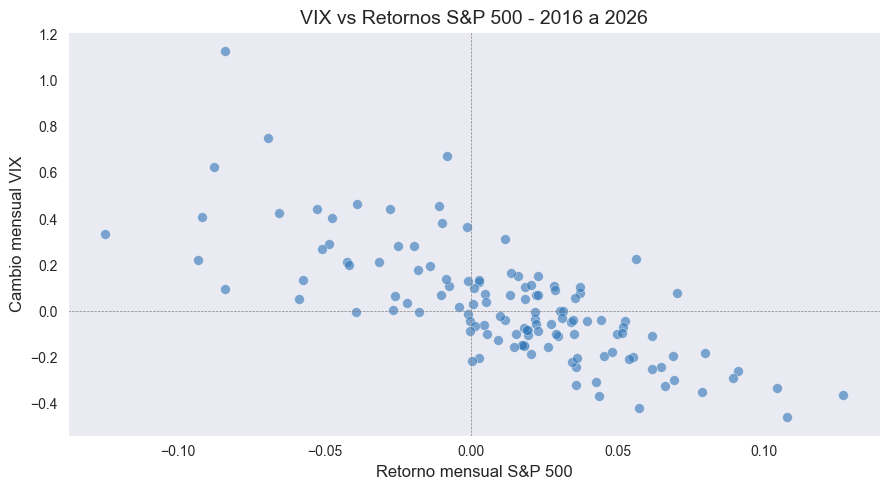

In [125]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df["r_SP500"], df["d_VIX"],
           alpha=0.6, color="#2E75B6", s=50,
           edgecolors="white", linewidth=0.4)

ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

ax.set_xlabel("Retorno mensual S&P 500", fontsize=12)
ax.set_ylabel("Cambio mensual VIX", fontsize=12)
ax.set_title("VIX vs Retornos S&P 500 - 2016 a 2026", fontsize=14)

plt.tight_layout()
plt.show

In [126]:
# Interpretación:
# El gráfico presenta una relación negativa entre el S&P 500 y el VIX. A medida que mayor es el retorno, baja el VIX.

In [127]:
# Paso 3 - 4: Modelo de Regresión Simple

import statsmodels.api as sm

# Variable independiente X -> retorno S&P 500
# Variable dependiente Y -> cambio VIX
X = sm.add_constant(df["r_SP500"]) # agrega la columna del intercepto
y = df["d_VIX"]

# Estimar modelo OLS (MCO)
modelo_simple = sm.OLS(y, X).fit()

# Resultados
print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_VIX   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     152.1
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           3.06e-23
Time:                        22:47:07   Log-Likelihood:                 47.525
No. Observations:                 125   AIC:                            -91.05
Df Residuals:                     123   BIC:                            -85.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0758      0.015      4.904      0.0

In [128]:
# Modelo estimado: d_VIX = 0.0765 + (-4.2274) x r_SP500
# R² -> El modelo explica el 55.4% de la variabilidad en los cambios del VIX.
# F-Statistic ->  El modelo es significativo.
# Prob(F) -> Tendencia a cero; se rechaza H₀ de que β₁ = 0

# Coeficientes
# Constante (0.0765, p < 0.001) -> Cuando el retorno del S&P 500 es 0%, el VIX sube en promedio un 7.65% mensual. Hay una presión alcista natural sobre la volatilidad.
# r_SP500 (-4.2274, p < 0.001) -> Por cada 1% de retorno adicional en el S&P, el VIX cae en promedio un 4.23%. Relación inversa.

# Diagnóstico de los residuos
# Sin autocorrelación según prueba de Durbin-Watson (2.377)
# Los residuos NO son normales según Jarque-Bera (p≈0)
# Asimetría positiva (cola derecha) según Skewness (0.968)
# Distribución leptocúrtica (colas pesadas) según prueba de Kurtosis (5.312)
# Sin problemas de multicolinealidad

# La relación negativa entre retornos del S&P 500 y cambios del VIX está bien capturada (R² = 55%), pero los residuos no son normales (colas pesadas, asimetría). Esto sugiere que en períodos de estrés extremo, hay desvíos grandes no capturados por el modelo lineal.

In [129]:
# Paso 5: Establecer una prueba de hipótesis para el parámetro de interés

# Hipótesis nula H0: β = 0; El S&P 500 no explica el VIX
# Hipótesis alternativa H1: β = 1; El S&P 500 sí explica el VIX

# p-valor < 0.05  →  Rechazamos H₀  →  β es significativo
# p-valor > 0.05  →  No rechazamos H₀  →  β no es significativo

# Extraer coeficientes del modelo
beta  = modelo_simple.params['r_SP500']   # el β estimado
error = modelo_simple.bse['r_SP500']      # error estándar de β
tstat = modelo_simple.tvalues['r_SP500']  # estadístico t
pval  = modelo_simple.pvalues['r_SP500']  # p-valor

print(f"β estimado      : {beta:.4f}")
print(f"Error estándar  : {error:.4f}")
print(f"Estadístico t   : {tstat:.4f}")
print(f"p-valor         : {pval:.4f}")


β estimado      : -4.2222
Error estándar  : 0.3424
Estadístico t   : -12.3315
p-valor         : 0.0000


In [130]:
print("─" * 45)
print("PRUEBA DE HIPÓTESIS SOBRE β")
print("─" * 45)
print(f"H₀: β = 0  →  S&P 500 no explica el VIX")
print(f"H₁: β ≠ 0  →  S&P 500 sí explica el VIX")
print("─" * 45)
print(f"β estimado      : {beta:.4f}")
print(f"Estadístico t   : {tstat:.4f}")
print(f"p-valor         : {pval:.4f}")
print("─" * 45)

if pval < 0.05:
    print(f"✓ p-valor ({pval:.4f}) < 0.05")
    print("→ Rechazamos H₀")
    print("→ β es estadísticamente significativo")
    print("→ El S&P 500 SÍ explica el cambio en el VIX")
else:
    print(f"✗ p-valor ({pval:.4f}) > 0.05")
    print("→ No rechazamos H₀")
    print("→ β no es estadísticamente significativo")
print("-" * 45)

─────────────────────────────────────────────
PRUEBA DE HIPÓTESIS SOBRE β
─────────────────────────────────────────────
H₀: β = 0  →  S&P 500 no explica el VIX
H₁: β ≠ 0  →  S&P 500 sí explica el VIX
─────────────────────────────────────────────
β estimado      : -4.2222
Estadístico t   : -12.3315
p-valor         : 0.0000
─────────────────────────────────────────────
✓ p-valor (0.0000) < 0.05
→ Rechazamos H₀
→ β es estadísticamente significativo
→ El S&P 500 SÍ explica el cambio en el VIX
---------------------------------------------


In [131]:
# Ajustar el modelo de regresión y mostrar visualmente
# Rango de valores para dibujar la recta
x_range = np.linspace(df["r_SP500"].min(),
                      df["r_SP500"].max(), 200)

# Aplicamos la ecuación: y = α + β * x
y_pred = (modelo_simple.params["const"] + modelo_simple.params["r_SP500"] * x_range)

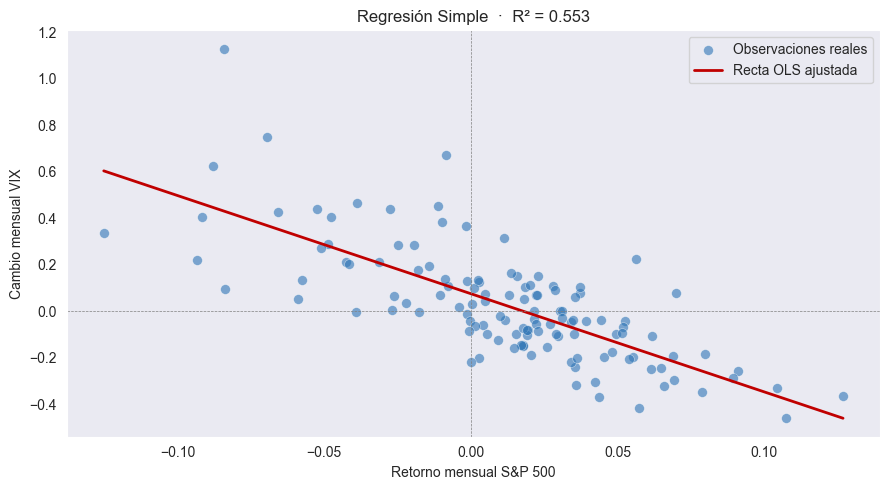

In [132]:
# Gráfico
fig, ax = plt.subplots(figsize=(9, 5))

# ── Puntos reales ─────────────────────────────
ax.scatter(df['r_SP500'], df['d_VIX'],
           alpha=0.6,
           color='#2E75B6',
           s=50,
           edgecolors='white',
           linewidth=0.4,
           label='Observaciones reales')

# ── Recta de regresión ────────────────────────
ax.plot(x_range, y_pred,
        color='#C00000',
        linewidth=2,
        label='Recta OLS ajustada')

# ── Líneas de referencia ──────────────────────
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

# ── Etiquetas ─────────────────────────────────
ax.set_xlabel('Retorno mensual S&P 500')
ax.set_ylabel('Cambio mensual VIX')
ax.set_title(f'Regresión Simple  ·  R² = {modelo_simple.rsquared:.3f}')
ax.legend()

plt.tight_layout()
plt.show()

In [133]:
r2     = modelo_simple.rsquared
r2_adj = modelo_simple.rsquared_adj

print("─" * 45)
print("BONDAD DE AJUSTE DEL MODELO")
print("─" * 45)
print(f"R²            : {r2:.4f}  ({r2*100:.1f}%)")
print(f"R² ajustado   : {r2_adj:.4f}  ({r2_adj*100:.1f}%)")
print("─" * 45)
print(f"\nEl retorno del S&P 500 explica el {r2*100:.1f}%")
print(f"de la variación mensual del VIX.")
print(f"El {(1-r2)*100:.1f}% restante depende de otros factores")
print(f"no incluidos en este modelo.")
print(f"\n→ Se agregarán más variables en la Parte 2.")

─────────────────────────────────────────────
BONDAD DE AJUSTE DEL MODELO
─────────────────────────────────────────────
R²            : 0.5528  (55.3%)
R² ajustado   : 0.5492  (54.9%)
─────────────────────────────────────────────

El retorno del S&P 500 explica el 55.3%
de la variación mensual del VIX.
El 44.7% restante depende de otros factores
no incluidos en este modelo.

→ Se agregarán más variables en la Parte 2.


In [157]:
# Regresión Múltiple
# Construcción de nuevas variables

df["abs_r_SP500"] = df["r_SP500"].abs() # Retorno absoluto
df["r_SP500_lag"] = df["r_SP500"].shift(1) # Retorno rezagado (mes anterior)
df["d_vol"] = df["Vol_SP500"].pct_change() # Cambio en volumen
df["d_VIX_lag"] = df["d_VIX"].shift(1)
df = df.dropna()

print(df[['d_VIX', 'r_SP500', 'abs_r_SP500',
          'r_SP500_lag', 'd_vol', 'd_VIX_lag']].head(10))
print(f"\nObservaciones finales: {len(df)}")



               d_VIX   r_SP500  abs_r_SP500  r_SP500_lag     d_vol  d_VIX_lag
2016-04-30  0.125448  0.002699     0.002699     0.065991 -0.124293  -0.321168
2016-05-31 -0.096178  0.015325     0.015325     0.002699 -0.027629   0.125448
2016-06-30  0.101480  0.000911     0.000911     0.015325  0.101024  -0.096178
2016-07-31 -0.240563  0.035610     0.035610     0.000911 -0.199446   0.101480
2016-08-31  0.130581 -0.001219     0.001219     0.035610  0.087445  -0.240563
2016-09-30 -0.009687 -0.001234     0.001234    -0.001219  0.018692   0.130581
2016-10-31  0.283672 -0.019426     0.019426    -0.001234 -0.053335  -0.009687
2016-11-30 -0.218640  0.034175     0.034175    -0.019426  0.212984   0.283672
2016-12-31  0.053263  0.018201     0.018201     0.034175 -0.148123  -0.218640
2017-01-31 -0.146011  0.017884     0.017884     0.018201 -0.063284   0.053263

Observaciones finales: 123


In [160]:
# Seleccionar solo las variables del modelo
variables = ['d_VIX', 'r_SP500', 'abs_r_SP500',
             'r_SP500_lag', 'd_vol', 'd_VIX_lag']

correlacion = df[variables].corr()
print(correlacion.round(3))

             d_VIX  r_SP500  abs_r_SP500  r_SP500_lag  d_vol  d_VIX_lag
d_VIX        1.000   -0.740       -0.049        0.257  0.244     -0.219
r_SP500     -0.740    1.000        0.092       -0.144 -0.324      0.028
abs_r_SP500 -0.049    0.092        1.000       -0.345  0.044      0.257
r_SP500_lag  0.257   -0.144       -0.345        1.000 -0.111     -0.744
d_vol        0.244   -0.324        0.044       -0.111  1.000      0.257
d_VIX_lag   -0.219    0.028        0.257       -0.744  0.257      1.000


**Relaciones con la variable dependiente.**

r_SP500 -> Relación negativa fuerte. Es el principal predictor: cuando el S&P500 sube, el VIX cae. Confirma el resultado del modelo simple.

r_SP500_lag -> Positiva moderada- El retorno del mes anterior tiene un efecto rezagado sobre el VIX actual.

d_vol -> Positiva moderada. Mayor volumen de operaciones se asocia a mayor incertidumbre (VIX sube).

d_VIX_lag -> Negativa débil. Hay cierta reversión a la media: un VIX que subió el mes pasado tiende a caer este mes.

abs_r_SP500 -> Prácticamente nula. La magnitud del retorno no predice el VIX; lo que importa es la dirección (positiva o negativa).

**Estimar el modelo de regresión múltiple con las variables adicionales**

Ecuación del modelo: ΔVIXt​=α+β1​⋅rSP500,t​+β2​⋅∣rSP500,t​∣+β3​⋅rSP500,t−1​+β4​⋅ΔVolt​+β5​⋅ΔVIXt−1​+εt​

In [190]:
# Variables independientes
X = df[['r_SP500', 'abs_r_SP500', 'r_SP500_lag', 'd_vol', 'd_VIX_lag']]
X = sm.add_constant(X) # Agregar constante (intercepto)
y = df['d_VIX'] # Variable dependiente (Y)
modelo_multiple = sm.OLS(y, X).fit() # Estimar modelo OLS

print(modelo_multiple.summary()) # Resultados


                            OLS Regression Results                            
Dep. Variable:                  d_VIX   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     34.66
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           1.33e-21
Time:                        00:39:30   Log-Likelihood:                 53.153
No. Observations:                 123   AIC:                            -94.31
Df Residuals:                     117   BIC:                            -77.43
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0526      0.027      1.938      

**Interpretación**

r_SP500 → p-valor = 0.000

El más significativo del modelo. Evidencia contundente de que el retorno del S&P 500 explica el VIX.

d_VIX_lag → p-valor = 0.021

Significativo al 5%. Confirma que la volatilidad tiene memoria — lo que pasó el mes pasado importa.

const → p-valor = 0.055

Está en el límite — marginalmente no significativo al 5% pero sí al 10%. En la práctica se suele mantener en el modelo.

abs_r_SP500, r_SP500_lag, d_vol → p-valores altos

No hay evidencia suficiente para rechazar H₀. Una vez que el modelo controla por r_SP500, estas variables no agregan información adicional significativa.